Total responses: 79

First few rows:
                Timestamp Are you a full-time undergraduate UVA student?  \
0 2026-01-14 14:54:43.655                                            Yes   
1 2026-01-14 14:55:13.908                                            Yes   
2 2026-01-14 14:56:48.883                                            Yes   
3 2026-01-14 14:58:15.394                                            Yes   
4 2026-01-14 14:58:24.763                                            Yes   

  What year are you? Do you believe a hotdog is a sandwich?  
0                3rd                                     No  
1                4th                                     No  
2                4th                                     No  
3                4th                                    Yes  
4                4th                                    Yes  
UVA students only: 76 responses


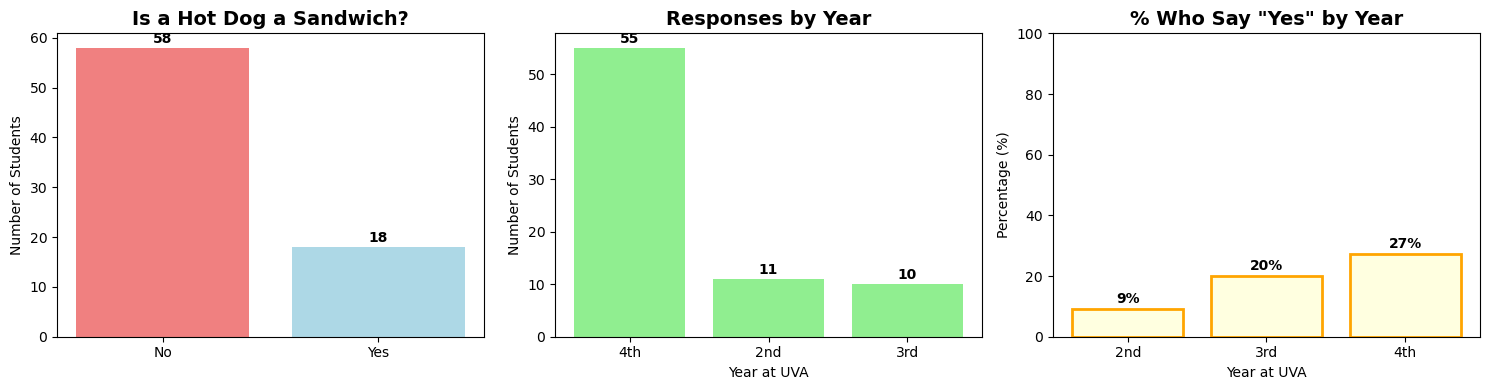


BIAS

1. Year Representation:
   1st: 0 students (0.0%)
   2nd: 11 students (14.5%)
   3rd: 10 students (13.2%)
   4th: 55 students (72.4%)

2. Opinion by Year:
   2nd: 9.1% say Yes
   3rd: 20.0% say Yes
   4th: 27.3% say Yes

CONCLUSIONS

Out of 76 UVA students:
18 say YES (23.7%) - hot dog IS a sandwich
58 say NO (76.3%) - hot dog IS NOT a sandwich


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel('Hotdog Survey (Responses).xlsx')

print("Total responses:", len(df))
print("\nFirst few rows:")
print(df.head())

# Filter for only UVA students
df_uva = df[df['Are you a full-time undergraduate UVA student?'] == 'Yes']
print(f"UVA students only: {len(df_uva)} responses")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Is a hot dog a sandwich?
sandwich_counts = df_uva['Do you believe a hotdog is a sandwich?'].value_counts()
axes[0].bar(sandwich_counts.index, sandwich_counts.values, color=['lightcoral','lightblue'])
axes[0].set_title('Is a Hot Dog a Sandwich?', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(sandwich_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

#Number of responses by year
year_counts = df_uva['What year are you?'].value_counts()
axes[1].bar(year_counts.index, year_counts.values, color='lightgreen')
axes[1].set_title('Responses by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year at UVA')
axes[1].set_ylabel('Number of Students')
for i, (year, count) in enumerate(year_counts.items()):
    axes[1].text(i, count + 1, str(count), ha='center', fontweight='bold')

#Opinion by year 
year_opinion = df_uva.groupby('What year are you?')['Do you believe a hotdog is a sandwich?'].apply(lambda x: (x == 'Yes').sum())
year_total = df_uva['What year are you?'].value_counts()
year_pct = (year_opinion / year_total * 100).sort_index()
axes[2].bar(year_pct.index, year_pct.values, color='lightyellow', edgecolor='orange', linewidth=2)
axes[2].set_title('% Who Say "Yes" by Year', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year at UVA')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_ylim(0, 100)
for i, (year, pct) in enumerate(year_pct.items()):
    axes[2].text(i, pct + 2, f'{pct:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()




print("\nBIAS")

# Are all years equally represented?
print("\n1. Year Representation:")
for year in ['1st', '2nd', '3rd', '4th']:
    count = (df_uva['What year are you?'] == year).sum()
    pct = count / len(df_uva) * 100
    print(f"   {year}: {count} students ({pct:.1f}%)")

#Do opinions differ by year?
print("\n2. Opinion by Year:")
for year in ['1st', '2nd', '3rd', '4th']:
    year_data = df_uva[df_uva['What year are you?'] == year]
    if len(year_data) > 0:
        yes_pct = (year_data['Do you believe a hotdog is a sandwich?'] == 'Yes').sum() / len(year_data) * 100
        print(f"   {year}: {yes_pct:.1f}% say Yes")



print("\nCONCLUSIONS")

yes_count = (df_uva['Do you believe a hotdog is a sandwich?'] == 'Yes').sum()
no_count = (df_uva['Do you believe a hotdog is a sandwich?'] == 'No').sum()
yes_pct = yes_count / len(df_uva) * 100
no_pct = no_count / len(df_uva) * 100

print(f"\nOut of {len(df_uva)} UVA students:")
print(f"{yes_count} say YES ({yes_pct:.1f}%) - hot dog IS a sandwich")
print(f"{no_count} say NO ({no_pct:.1f}%) - hot dog IS NOT a sandwich")

